In [13]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

from combine_features import read_data

plt.style.use('default')

In [2]:
df = read_data("../rhea-soil-nutrient-prediction-challenge/Train.csv")
df.head()

,ID,Longitude,Latitude,Depth_cm,ph,Area,Cropland nitrogen per unit area,Cropland phosphorus per unit area,Cropland potassium per unit area,tmin_avg,...,Cu,Fe,Mg,Mn,N,P,K,Na,S,Zn
0,BF9XTB,37.65189,-3.15440,20-50,6.405,Kenya,14.202173,3.902236,-7.263155,15.240530,...,5.826,81.780,306.836,270.240,0.79,NaN,300.951,NaN,NaN,NaN
1,2RWYTR,37.63612,-3.08585,20-50,6.419,Kenya,14.202173,3.902236,-7.263155,15.240530,...,4.346,97.198,407.980,185.557,1.11,NaN,292.696,NaN,NaN,NaN
2,XZI9Q6,39.55580,-2.67218,20-50,8.388,Kenya,14.202173,3.902236,-7.263155,21.969696,...,3.657,42.672,1256.319,178.299,0.45,NaN,814.911,NaN,NaN,NaN
3,4CBCVY,39.55477,-2.67196,20-50,8.302,Kenya,14.202173,3.902236,-7.263155,21.969696,...,3.376,52.861,1322.732,464.137,0.31,NaN,815.337,NaN,NaN,NaN
4,F9GK9S,39.55477,-2.67196,20-50,8.292,Kenya,14.202173,3.902236,-7.263155,21.969696,...,3.351,46.057,1134.898,274.565,0.45,NaN,928.238,NaN,NaN,NaN


In [3]:
df.describe()

,Longitude,Latitude,ph,Cropland nitrogen per unit area,Cropland phosphorus per unit area,Cropland potassium per unit area,tmin_avg,tmax_avg,prec_avg,B11,...,Cu,Fe,Mg,Mn,N,P,K,Na,S,Zn
count,13454.000000,13454.000000,13454.000000,13454.000000,13454.000000,13454.000000,13454.000000,13454.000000,13454.000000,13454.000000,...,13416.000000,13416.000000,13454.000000,13416.000000,13416.000000,0.0,13454.000000,38.000000,0.0,0.0
mean,15.954240,-1.435910,6.377333,9.673053,-1.142163,-8.216477,18.817286,30.518811,92.404167,2856.805387,...,2.147924,108.054510,354.537552,122.635291,1.045487,NaN,201.850648,32.149763,NaN,NaN
std,19.705884,12.912814,0.931209,14.714714,1.854313,7.034999,3.979297,3.364608,37.165095,874.438765,...,1.396735,41.110409,401.796434,69.241625,0.792512,NaN,224.419425,17.616898,NaN,NaN
min,-13.433100,-24.245060,2.270000,-3.442173,-2.796745,-18.097209,7.232954,22.348484,29.341862,597.500000,...,0.002000,19.095000,4.995000,0.023000,0.070000,NaN,9.850000,7.590000,NaN,NaN
25%,-2.227772,-14.752010,5.835000,-0.403955,-2.550627,-15.638227,15.462121,27.878788,63.800938,2227.000000,...,1.018000,82.394250,126.410500,74.190500,0.530000,NaN,77.842250,17.997500,NaN,NaN
50%,15.174680,5.393690,6.226000,8.639418,-1.461318,-7.520327,20.399622,30.744318,95.865320,2758.650000,...,1.928000,104.183000,197.837000,113.642000,0.820000,NaN,119.046000,27.945000,NaN,NaN
75%,35.504850,9.582735,6.702000,12.434945,-0.612673,-3.758418,22.261364,33.250000,112.544876,3347.642857,...,3.001250,130.167500,373.472250,163.956500,1.300000,NaN,218.261750,47.322500,NaN,NaN
max,48.763800,14.886790,9.914000,56.498218,3.902236,7.334409,23.664772,37.537880,238.184100,5877.333333,...,9.622000,457.031000,4485.197000,538.434000,10.050000,NaN,2941.056000,83.030000,NaN,NaN


In [4]:
def get_S(row):
    return row['N'] / 12.5

def get_B(row):
    value = row['N'] / 1000
    if row['Ca'] > 1500:
        return value * 0.6
    return value

def get_Zn(row):
    value = row['Mn'] / 10
    if row['ph'] > 6.0:
        penalty = (row['ph'] - 6.0) * 0.5
        value *= (1 - min(penalty, 0.9))
    return value

def get_Na(row):
    return 0

def get_P(row):
    return 0

In [5]:
df['S'] = df.apply(get_S, axis=1)
df['B'] = df.apply(get_B, axis=1)
df['Zn'] = df.apply(get_Zn, axis=1)
df['Na'] = df.apply(get_Na, axis=1)
df['P'] = df.apply(get_P, axis=1)

In [7]:
print(df['Area'].unique())

['Kenya' 'Ethiopia' 'Cameroon' 'Ghana' "Côte d'Ivoire" 'Guinea'
 'Burkina Faso' 'Mali' 'Niger' 'Mozambique' 'Botswana' 'Madagascar'
 'Angola' 'Malawi']


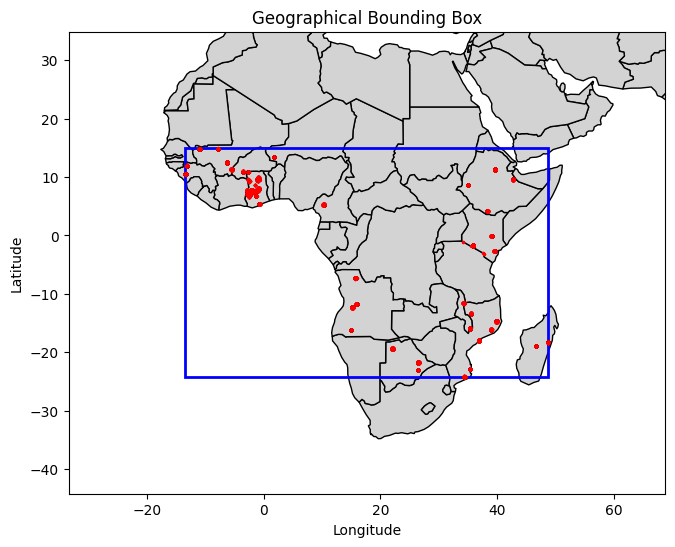

In [9]:
world = gpd.read_file('../assets/world_map/world.shp')
min_lon, max_lon = df['Longitude'].min(), df['Longitude'].max()
min_lat, max_lat = df['Latitude'].min(), df['Latitude'].max()

points = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['Longitude'], df['Latitude']))

fig, ax = plt.subplots(figsize=(10, 6))
world.plot(ax=ax, color='lightgray', edgecolor='black')

rect = plt.Rectangle((min_lon, min_lat), max_lon - min_lon, max_lat - min_lat, linewidth=2, edgecolor='blue', facecolor='none')
ax.add_patch(rect)

points.plot(ax=ax, color='red', markersize=2)

plt.title('Geographical Bounding Box')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

ax.set_xlim(min_lon - 20, max_lon + 20)
ax.set_ylim(min_lat - 20, max_lat + 20)

plt.show()

In [11]:
target = [
    "Al",
    "B",
    "Ca",
    "Cu",
    "Fe",
    "Mg",
    "Mn",
    "N",
    "P",
    "K",
    "Na",
    "S",
    "Zn",
]

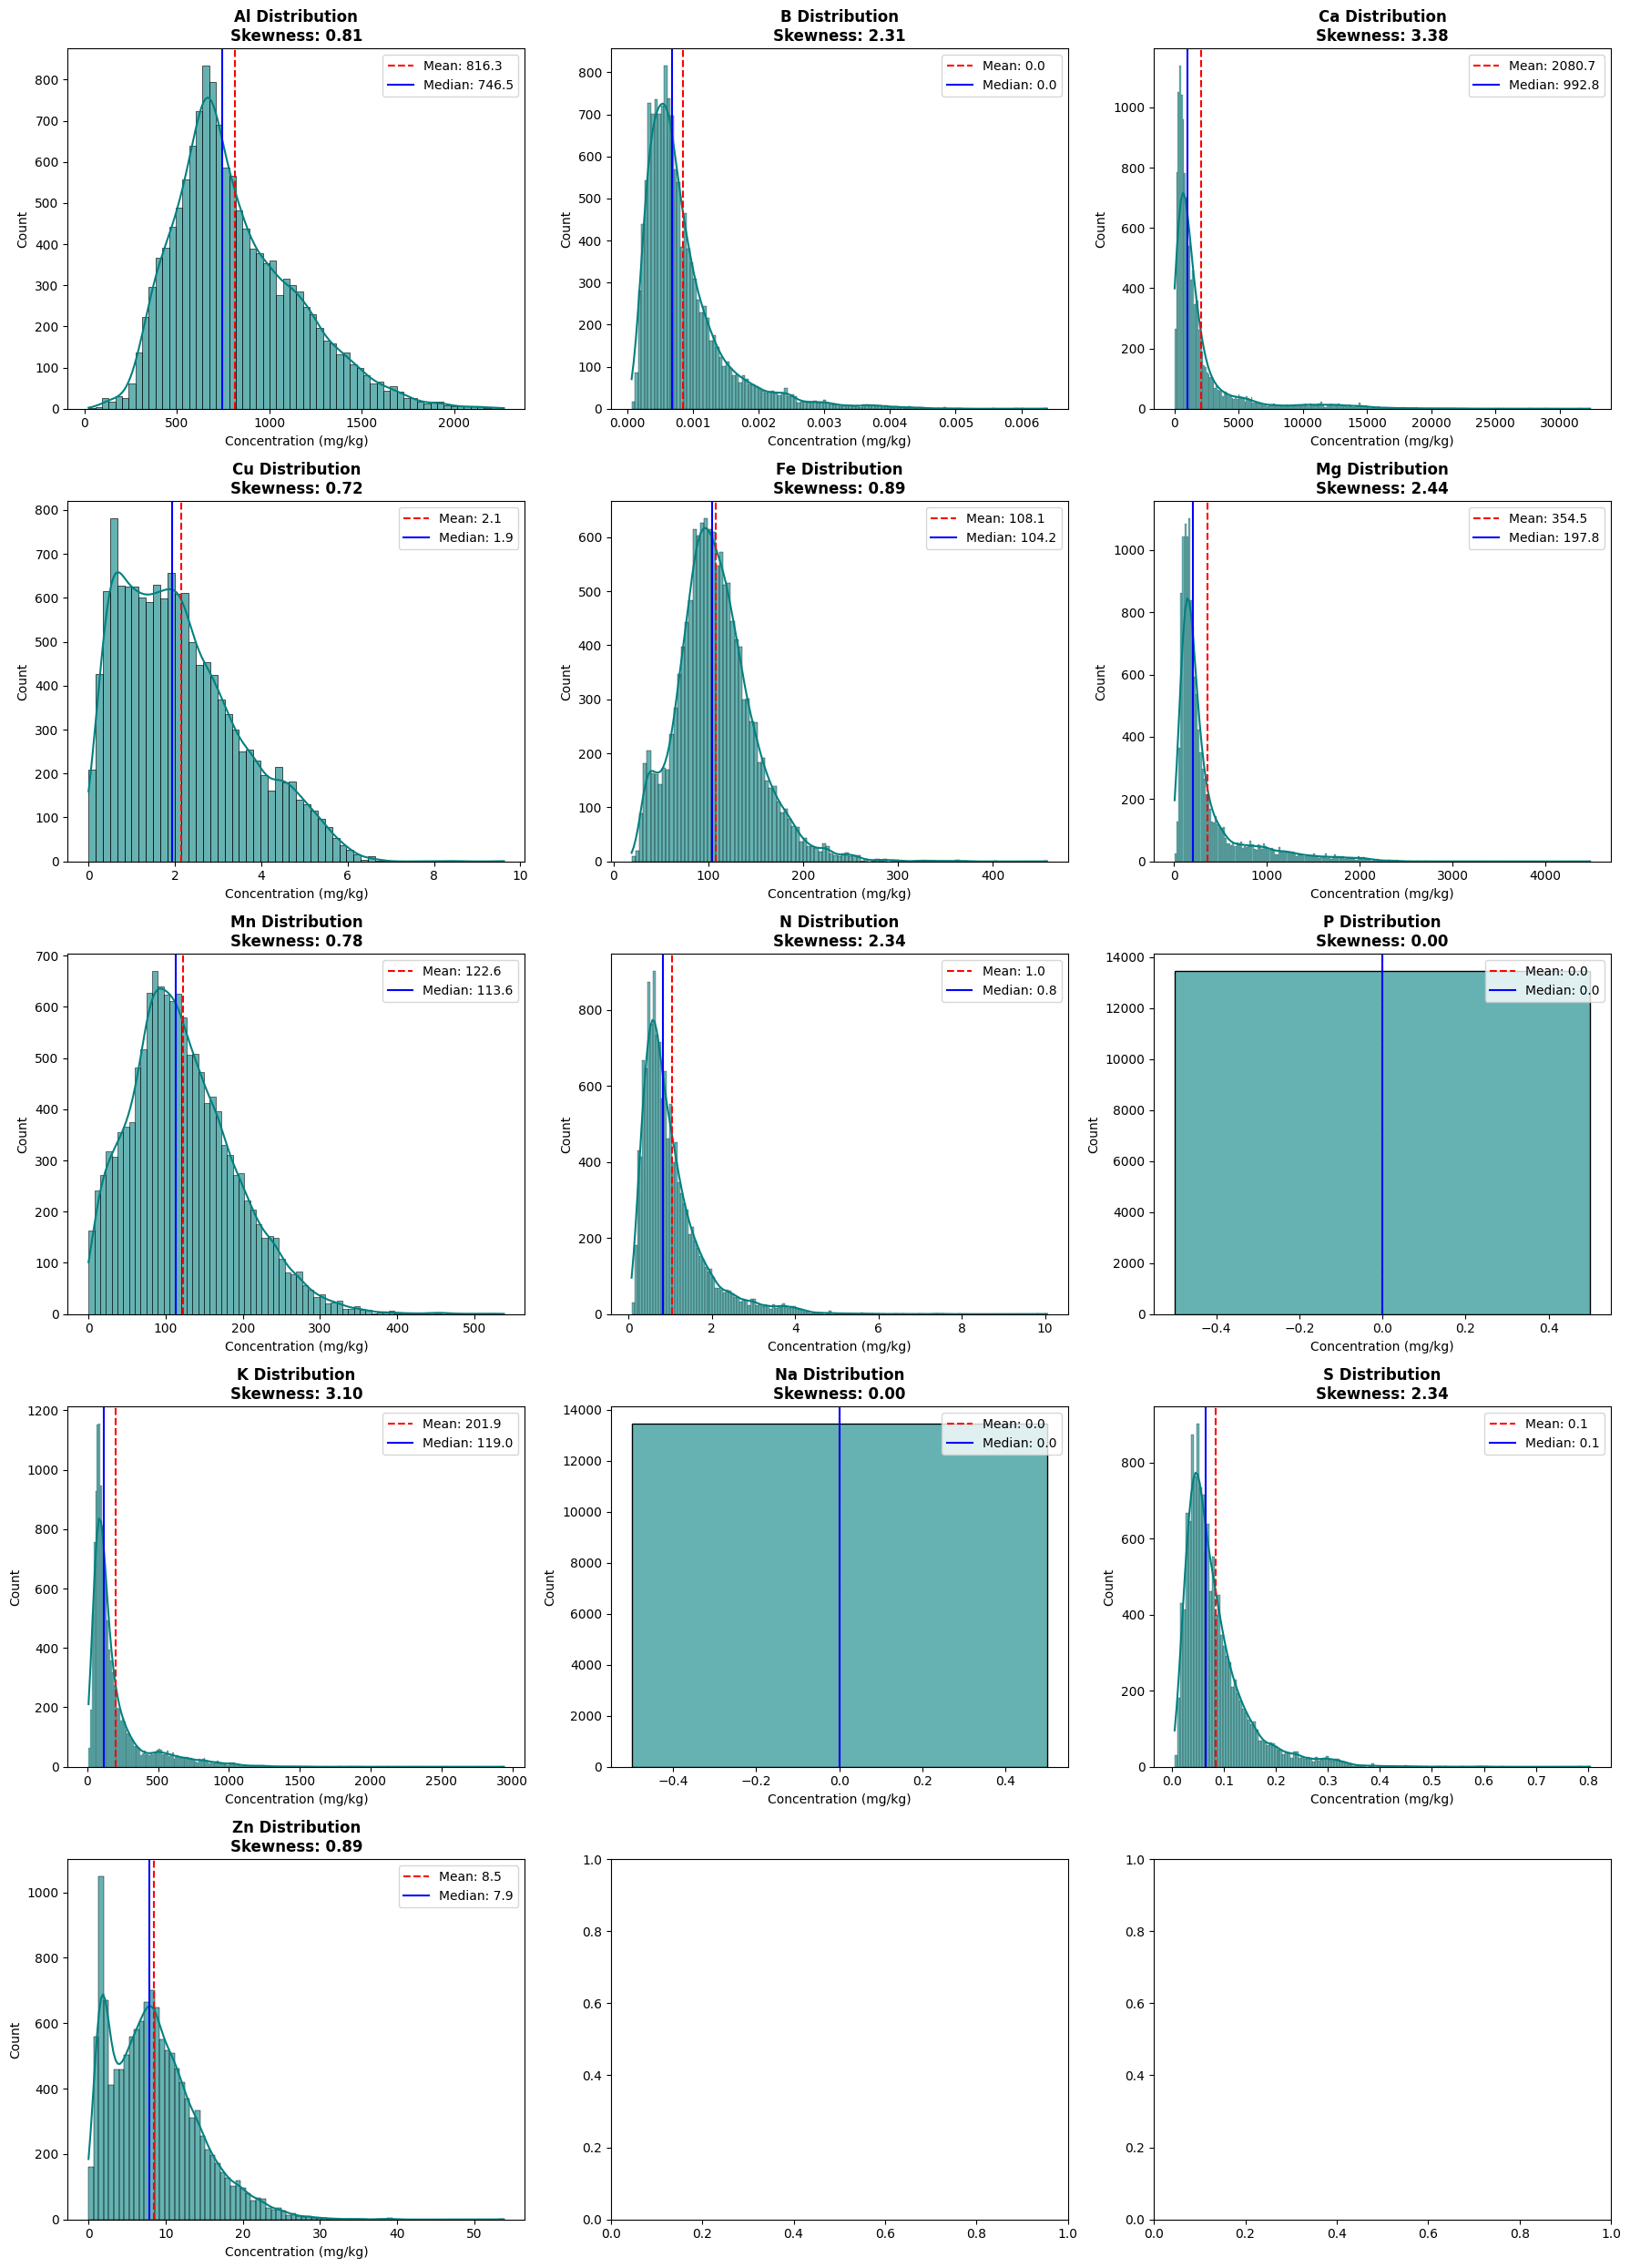

In [ ]:
n_cols = 3
n_rows = (len(target) + 1) // n_cols + 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, nutrient in enumerate(target):
    if nutrient not in df.columns:
        continue
        
    ax = axes[i]
    
    sns.histplot(df[nutrient], kde=True, ax=ax, color='teal', edgecolor='black', alpha=0.6)
    
    mean_val = df[nutrient].mean()
    median_val = df[nutrient].median()
    skewness = df[nutrient].skew()
    
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    ax.axvline(median_val, color='blue', linestyle='-', linewidth=1.5, label=f'Median: {median_val:.1f}')
    
    ax.set_title(f"{nutrient} Distribution\nSkewness: {skewness:.2f}", fontweight='bold')
    ax.set_xlabel(f"Concentration (mg/kg)")
    ax.legend()

plt.tight_layout()
plt.show()

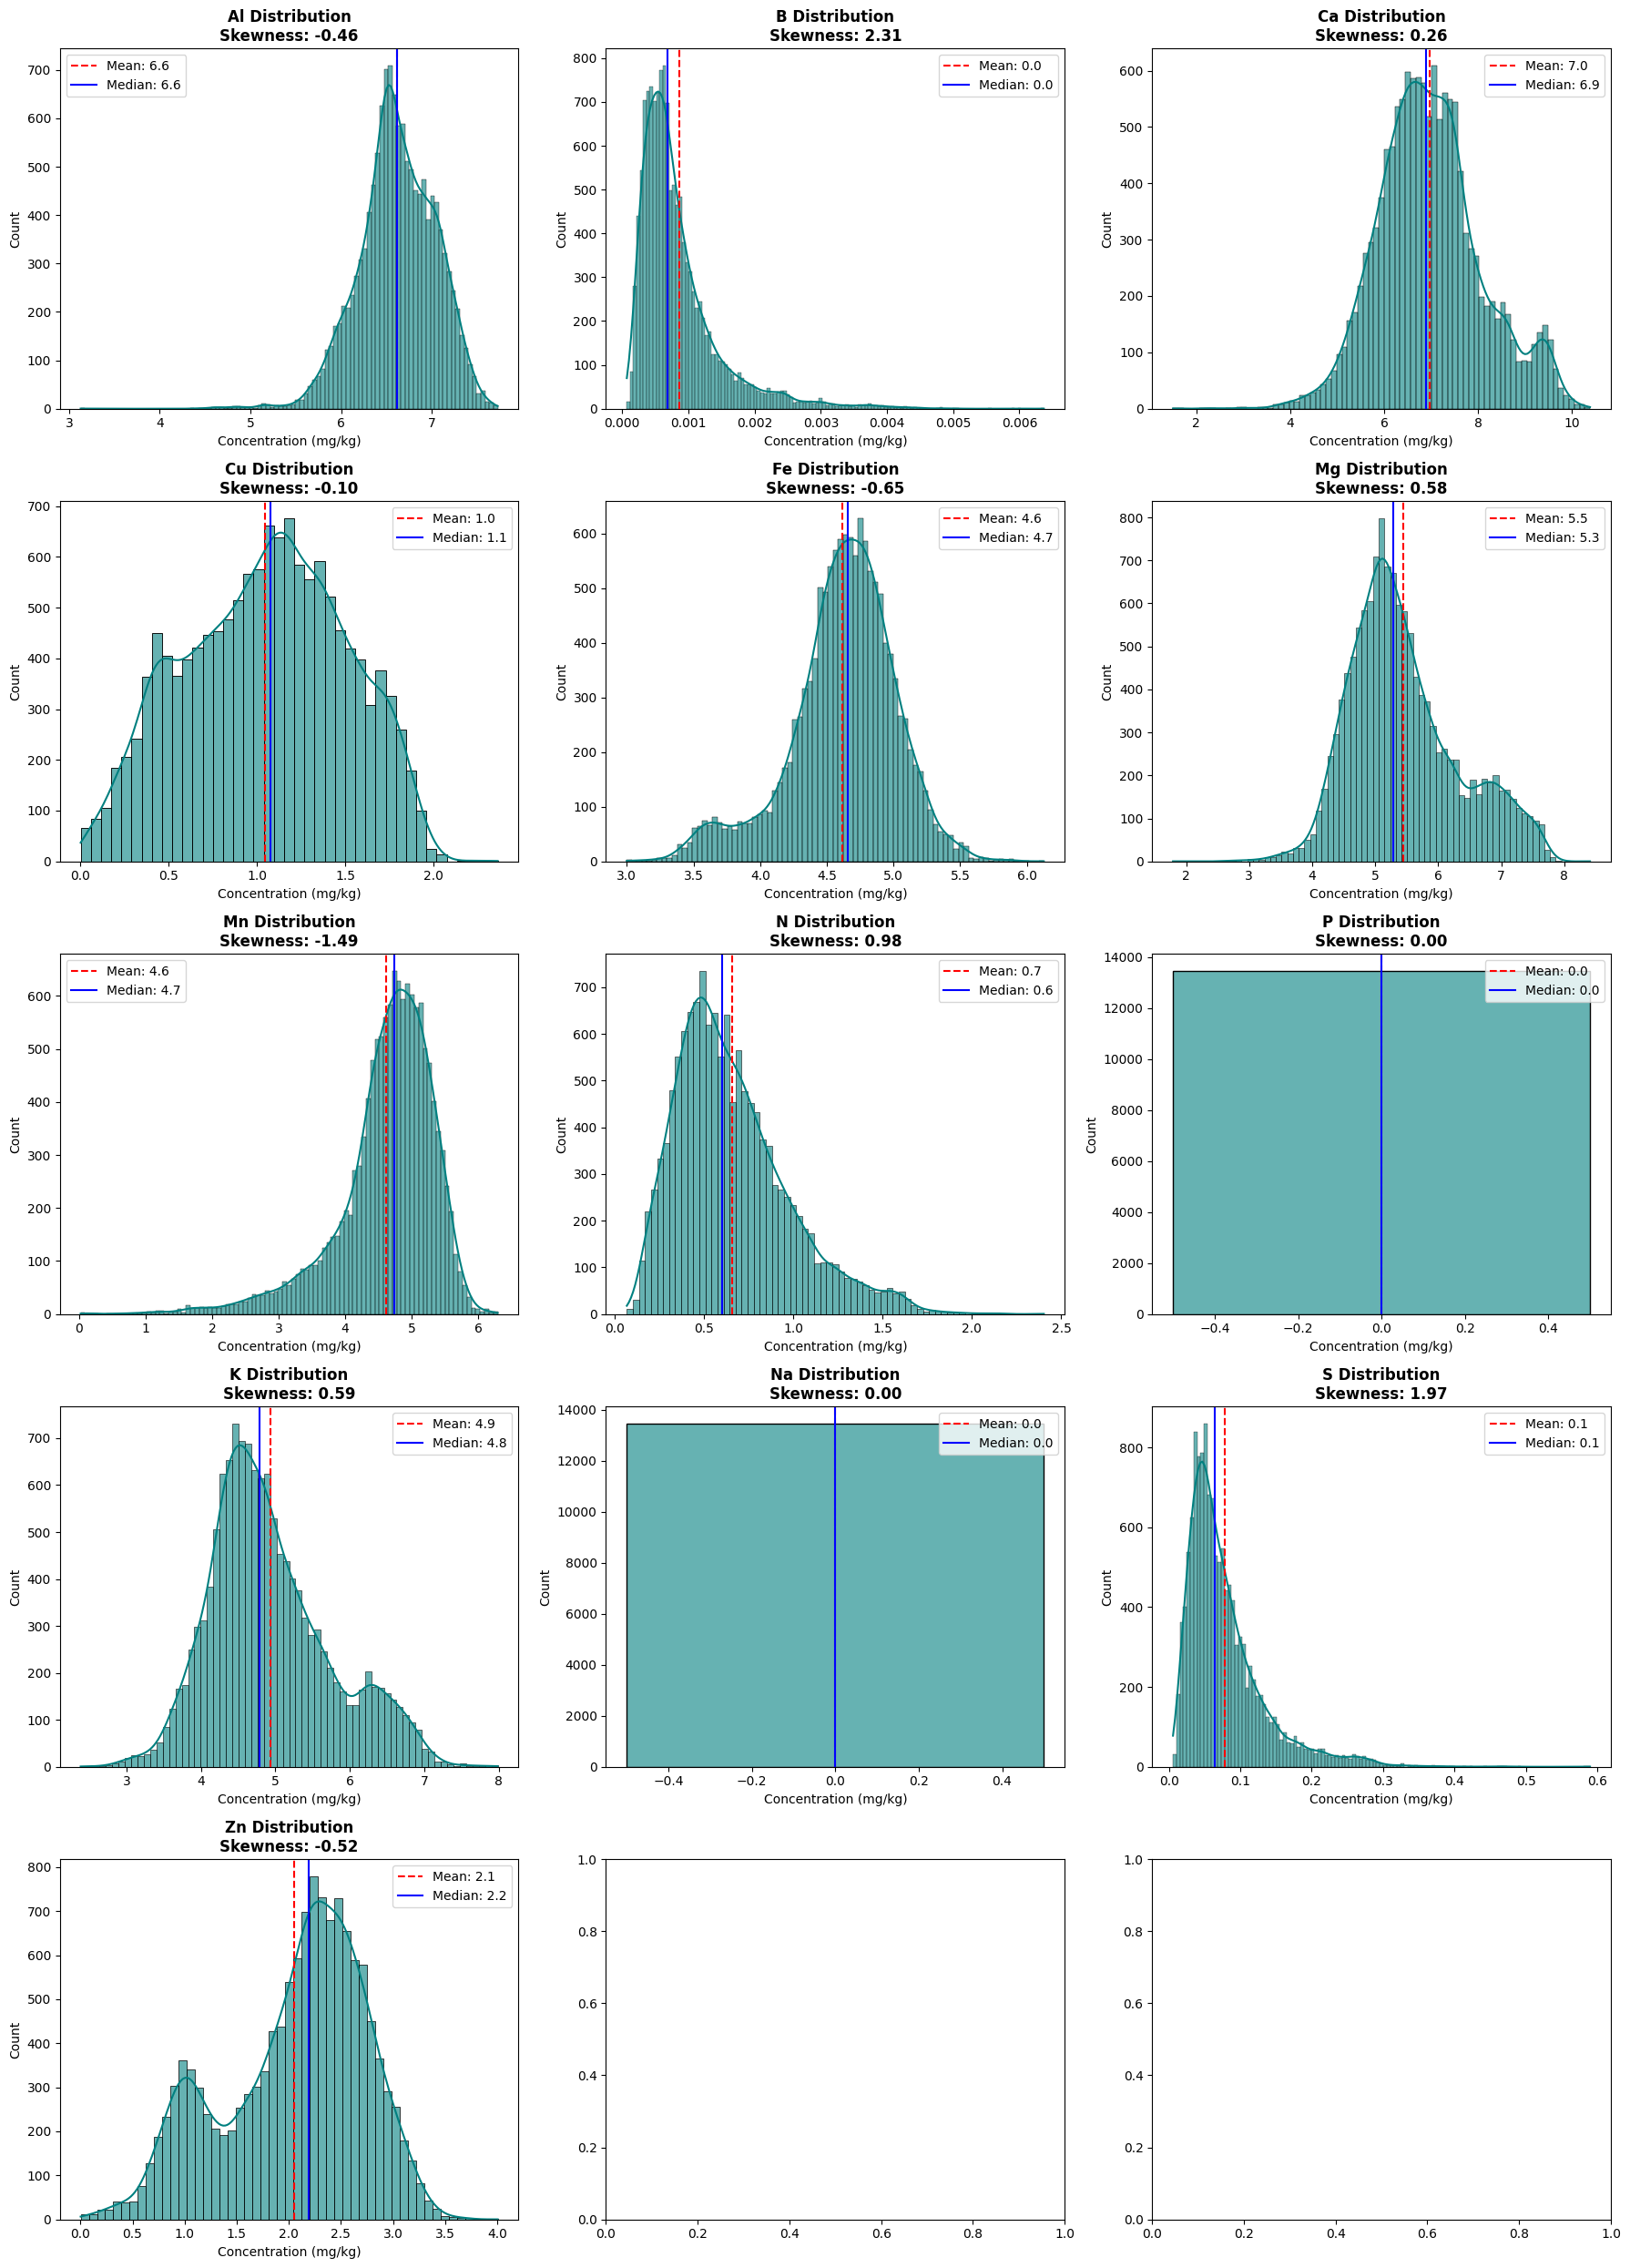

In [18]:
n_cols = 3
n_rows = (len(target) + 1) // n_cols + 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, nutrient in enumerate(target):
    if nutrient not in df.columns:
        continue
        
    ax = axes[i]
    data = np.log(df[nutrient] + 1)

    sns.histplot(data, kde=True, ax=ax, color='teal', edgecolor='black', alpha=0.6)

    mean_val = data.mean()
    median_val = data.median()
    skewness = data.skew()
    
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    ax.axvline(median_val, color='blue', linestyle='-', linewidth=1.5, label=f'Median: {median_val:.1f}')
    
    ax.set_title(f"{nutrient} Distribution\nSkewness: {skewness:.2f}", fontweight='bold')
    ax.set_xlabel(f"Concentration (mg/kg)")
    ax.legend()

plt.tight_layout()
plt.show()